Generating synthetic industrial image dataset...
Device: cuda
Loading frozen DINOv2 model from PyTorch Hub...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 222MB/s]


Extracting DINOv2 feature embeddings...
Training Logistic Regression classifier...

CLASSIFIER PERFORMANCE
Test Accuracy: 100.00%
Test ROC AUC: 1.0000

Computing SHAP values to explain feature importance...


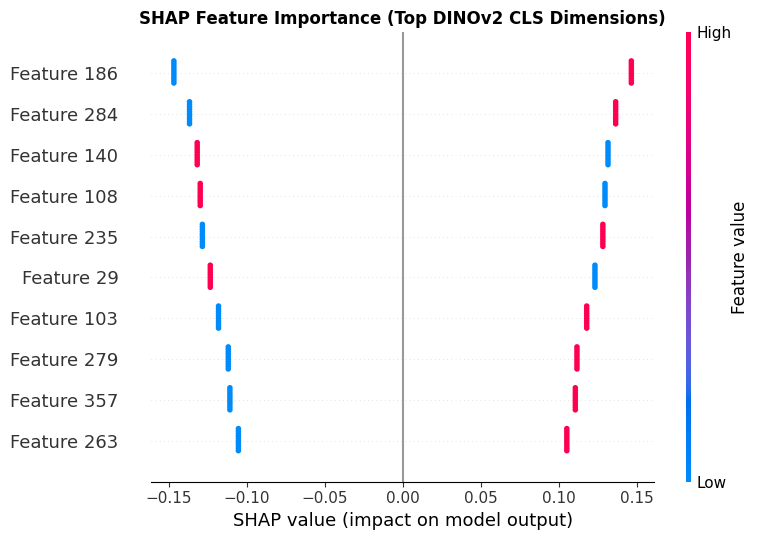

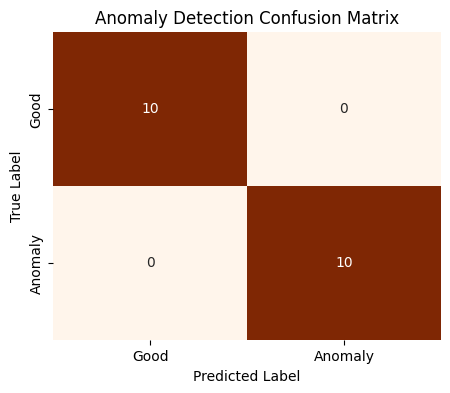

In [ ]:

# ==========================================
# Setup
# ==========================================

import os  # system tools
import warnings  # silence warnings
import numpy as np  # fast math
import pandas as pd  # data tables
import torch  # deep learning
import torch.nn as nn  # neural layers
import torchvision.transforms as T  # image edits
from PIL import Image, ImageDraw  # draw images
from sklearn.linear_model import LogisticRegression  # anomaly classifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix  # score metrics
import matplotlib.pyplot as plt  # plot graphs
import seaborn as sns  # plot styling

warnings.filterwarnings('ignore')  # hide warnings

SEED = 42  # standard seed
np.random.seed(SEED)  # seed numpy
torch.manual_seed(SEED)  # seed pytorch

# ==========================================
# Install SHAP & DINOv2 Dependencies
# ==========================================

try:
    import shap  # try loading shap
except ImportError:
    import subprocess  # terminal runner
    import sys  # system engine
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap'])  # install shap
    import shap  # load shap

# ==========================================
# Synthetic Industrial Data Generator
# ==========================================

def create_synthetic_part(has_anomaly=False):
    img = Image.new('RGB', (224, 224), color='white')  # base image - Creates a 224x224 RGB image with white background - base canvas for synthetic part generation.
    draw = ImageDraw.Draw(img)  # drawing tool

    # Draw a clean metal circle (The "good" part)
    draw.ellipse([40, 40, 184, 184], fill='gray', outline='black', width=3) # ellipse: Draws a gray circle with black border - represents a clean metal part (normal sample). Bounding box coordinates [x1,y1,x2,y2].

    if has_anomaly:
        # Draw a black scratch/defect on the metal circle
        draw.line([100, 80, 150, 140], fill='black', width=5) # line: Draws a black scratch - represents surface defect (anomaly) on the metal part. Coordinates [start_x, start_y, end_x, end_y].
        draw.ellipse([120, 120, 135, 135], fill='black') # ellipse: Draws a small black spot - adds additional defect (anomaly) to the synthetic part, simulating contamination or pit.

    return img  # return image

# Generate training and test sets
print("Generating synthetic industrial image dataset...")  # status log
train_imgs = [create_synthetic_part(has_anomaly=(i % 2 == 1)) for i in range(40)]  # 40 train images
train_labels = np.array([i % 2 for i in range(40)])  # 0=good, 1=anomaly

test_imgs = [create_synthetic_part(has_anomaly=(i % 2 == 1)) for i in range(20)]  # 20 test images
test_labels = np.array([i % 2 for i in range(20)])  # 0=good, 1=anomaly

# ==========================================
# Feature Extraction (DINOv2 CLS)
# ==========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # check hardware
print(f"Device: {device}")  # print hardware

# Load ultra-fast DINOv2 model (ViT-S is lightweight and quick on CPU)
print("Loading frozen DINOv2 model from PyTorch Hub...")  # status log
dinov2_model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').to(device).eval()  # load dinov2

# ImageNet normalization transform used by DINOv2
dino_transforms = T.Compose([
    T.Resize(224),  # resize image
    T.CenterCrop(224),  # crop center
    T.ToTensor(),  # convert tensor
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # normalize channels
])

def extract_features(img_list):
    feats = []  # features list
    with torch.no_grad():  # freeze gradients
        for pil_img in img_list:  # loop images
            tensor = dino_transforms(pil_img).unsqueeze(0).to(device)  # transform image
            outputs = dinov2_model(tensor)  # run forward pass
            feats.append(outputs.cpu().numpy().flatten())  # save CLS embedding
    return np.array(feats)  # return array

print("Extracting DINOv2 feature embeddings...")  # status log
X_train = extract_features(train_imgs)  # extract train
X_test = extract_features(test_imgs)  # extract test

# ==========================================
# Train Anomaly Classifier
# ==========================================

print("Training Logistic Regression classifier...")  # status log
clf = LogisticRegression(max_iter=1000, class_weight='balanced')  # init model - LogisticRegression: Linear classifier with balanced class weights - automatically adjusts for imbalanced data, 1000 iterations max for convergence.
clf.fit(X_train, train_labels)  # train model

# Predict on test set
preds = clf.predict(X_test)  # predict labels
probs = clf.predict_proba(X_test)[:, 1]  # get probabilities

acc = accuracy_score(test_labels, preds)  # calculate accuracy
auc_score = roc_score = roc_auc_score(test_labels, probs)  # calculate ROC AUC

print("\n=====================================")
print("CLASSIFIER PERFORMANCE")
print("=====================================")
print(f"Test Accuracy: {acc * 100:.2f}%")  # print accuracy
print(f"Test ROC AUC: {auc_score:.4f}")  # print area score
print("=====================================")

# ==========================================
# Explain Decisions with SHAP
# ==========================================

print("\nComputing SHAP values to explain feature importance...")  # status log
# Use LinearExplainer to find out which DINOv2 feature indexes identify defects
explainer = shap.LinearExplainer(clf, X_train)  # load explainer
shap_values = explainer(X_test)  # calculate values

# Plot SHAP summary of top DINOv2 embedding indexes
plt.figure(figsize=(8, 5))  # canvas size
shap.summary_plot(shap_values, X_test, max_display=10, show=False)  # draw beeswarm
plt.title("SHAP Feature Importance (Top DINOv2 CLS Dimensions)", fontsize=12, fontweight='bold')  # plot title
plt.tight_layout()  # fit components
plt.show()  # display plot

# ==========================================
# Visualizing Confusion Matrix
# ==========================================

plt.figure(figsize=(5, 4))  # canvas size
sns.heatmap(confusion_matrix(test_labels, preds), annot=True, fmt='d', cmap='Oranges', cbar=False, xticklabels=['Good', 'Anomaly'], yticklabels=['Good', 'Anomaly'])  # draw heatmap
plt.xlabel('Predicted Label')  # x label
plt.ylabel('True Label')  # y label
plt.title('Anomaly Detection Confusion Matrix')  # title header
plt.show()  # display matrix plot